In [1]:
import pandas as pd
import numpy as np

In [2]:
gemini_data = pd.read_csv("gemini_results.csv", header=0, sep=",")

In [7]:
aug_rates = gemini_data["augmentation_rate"].unique().tolist()
means = []
lows = []
highs = []

for aug_rate in aug_rates:
    values = gemini_data[gemini_data["augmentation_rate"] == aug_rate]["code_similarity"].tolist()
    mean = np.mean(values)
    std = np.std(values)
    ci = 1.96 * std / np.sqrt(len(values))

    means.append(mean)
    lows.append(mean - ci)
    highs.append(mean + ci)

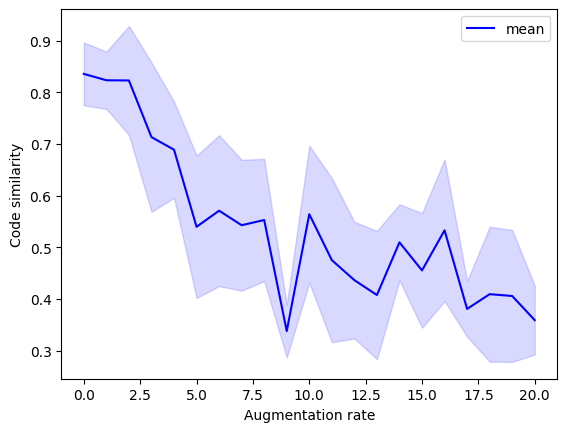

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(means,'-b', label='mean')
# fill the area with black color, opacity 0.15
plt.fill_between(list(range(len(means))), lows, highs, color="b", alpha=0.15)

plt.xlabel("Augmentation rate")
plt.ylabel("Code similarity")
plt.legend();